In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style= 'whitegrid', palette= 'muted')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 1. Loading Dataset

In [ ]:
# data path
data_path = r"" # <-- paste your data path here

# loading data
data = pd.read_csv(data_path)

# shape
print(f"Data shape: {data.shape}")

# head
data.head()

Data shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Our **goal** from the adult census income dataset is to predict whether a person has an income greater that **50k** per year or not. We will do that by fitting a **LogisticRegression** model.  
This data is messy and has a lot of categorical features, which needs to be handled carrefully and professionaly for model better performance.

## 2. Data Exploration

In [3]:
# infos about data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [4]:
# description of numeric features
data.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# description of categorical features
data.describe(include= 'object')

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [6]:
# checking for duplicates
data.duplicated().sum()

np.int64(24)

## 3. Preprocessing

In [7]:
# dropping duplicates
data = data.drop_duplicates()

In [8]:
# columns renaming
data.columns = data.columns.str.replace('.', '_')

In [9]:
# income unique values
data['income'].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [10]:
# handling the income feature
data['income'] = data['income'].map({'>50K': 1, '<=50K': 0})

In [11]:
# checking for errors
categ_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]

cat_unique_vals = {}

for col in categ_cols:
    cat_unique_vals[col] = data[col].unique().tolist()

cat_unique_vals

{'workclass': ['?',
  'Private',
  'State-gov',
  'Federal-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Local-gov',
  'Without-pay',
  'Never-worked'],
 'education': ['HS-grad',
  'Some-college',
  '7th-8th',
  '10th',
  'Doctorate',
  'Prof-school',
  'Bachelors',
  'Masters',
  '11th',
  'Assoc-acdm',
  'Assoc-voc',
  '1st-4th',
  '5th-6th',
  '12th',
  '9th',
  'Preschool'],
 'marital_status': ['Widowed',
  'Divorced',
  'Separated',
  'Never-married',
  'Married-civ-spouse',
  'Married-spouse-absent',
  'Married-AF-spouse'],
 'occupation': ['?',
  'Exec-managerial',
  'Machine-op-inspct',
  'Prof-specialty',
  'Other-service',
  'Adm-clerical',
  'Craft-repair',
  'Transport-moving',
  'Handlers-cleaners',
  'Sales',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv',
  'Armed-Forces',
  'Priv-house-serv'],
 'relationship': ['Not-in-family',
  'Unmarried',
  'Own-child',
  'Other-relative',
  'Husband',
  'Wife'],
 'race': ['White',
  'Black',
  'Asian-Pac-Islander',
  

We notice that there is a value of '?' in some features, which is an error and must be converted to a NaN value.

In [12]:
# handling errors
nan_features = [feature for feature in data.columns if '?' in data[feature].unique()]

for nan_feature in nan_features:
    data[nan_feature] = data[nan_feature].apply(lambda x: np.nan if x=='?' else x)

In [13]:
# checking for missing values
data.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     582
income               0
dtype: int64

## 4. Income Feature Analysis

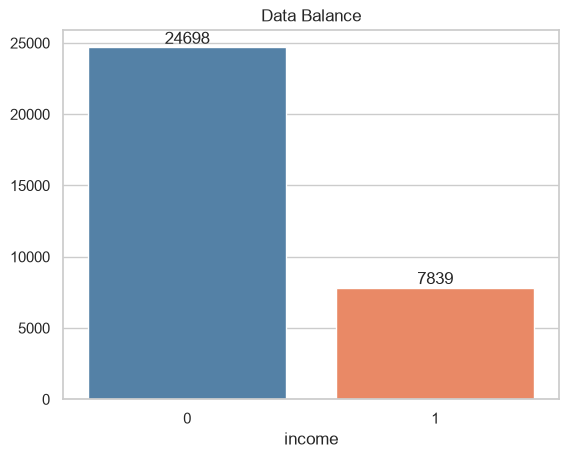

In [14]:
# income distribution
counts = data['income'].value_counts()
ax = sns.barplot(x= counts.index, y= counts.values, palette= ['steelblue', 'coral'])
for container in ax.containers:
    ax.bar_label(container)
ax.set_title(f"Data Balance")
plt.show()

In [15]:
# Percentages of income
print("Percentages of income: ")
print(f"<=50k: {(counts.values[0]/len(data))*100:.2f}%")
print(f">50k: {(counts.values[-1]/len(data))*100:.2f}%")

Percentages of income: 
<=50k: 75.91%
>50k: 24.09%


We see that the adult cencus income data is **imbalance**, and we need to fix this using the imbalance techniques.

## 5. Splitting Data Into Train & Test

In [16]:
X = data.drop(columns= ['income'])
y = data['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (26029, 14)
Test size: (6508, 14)


## 6. Missing Values

### 6.1. Missingness Distribution and Correlation

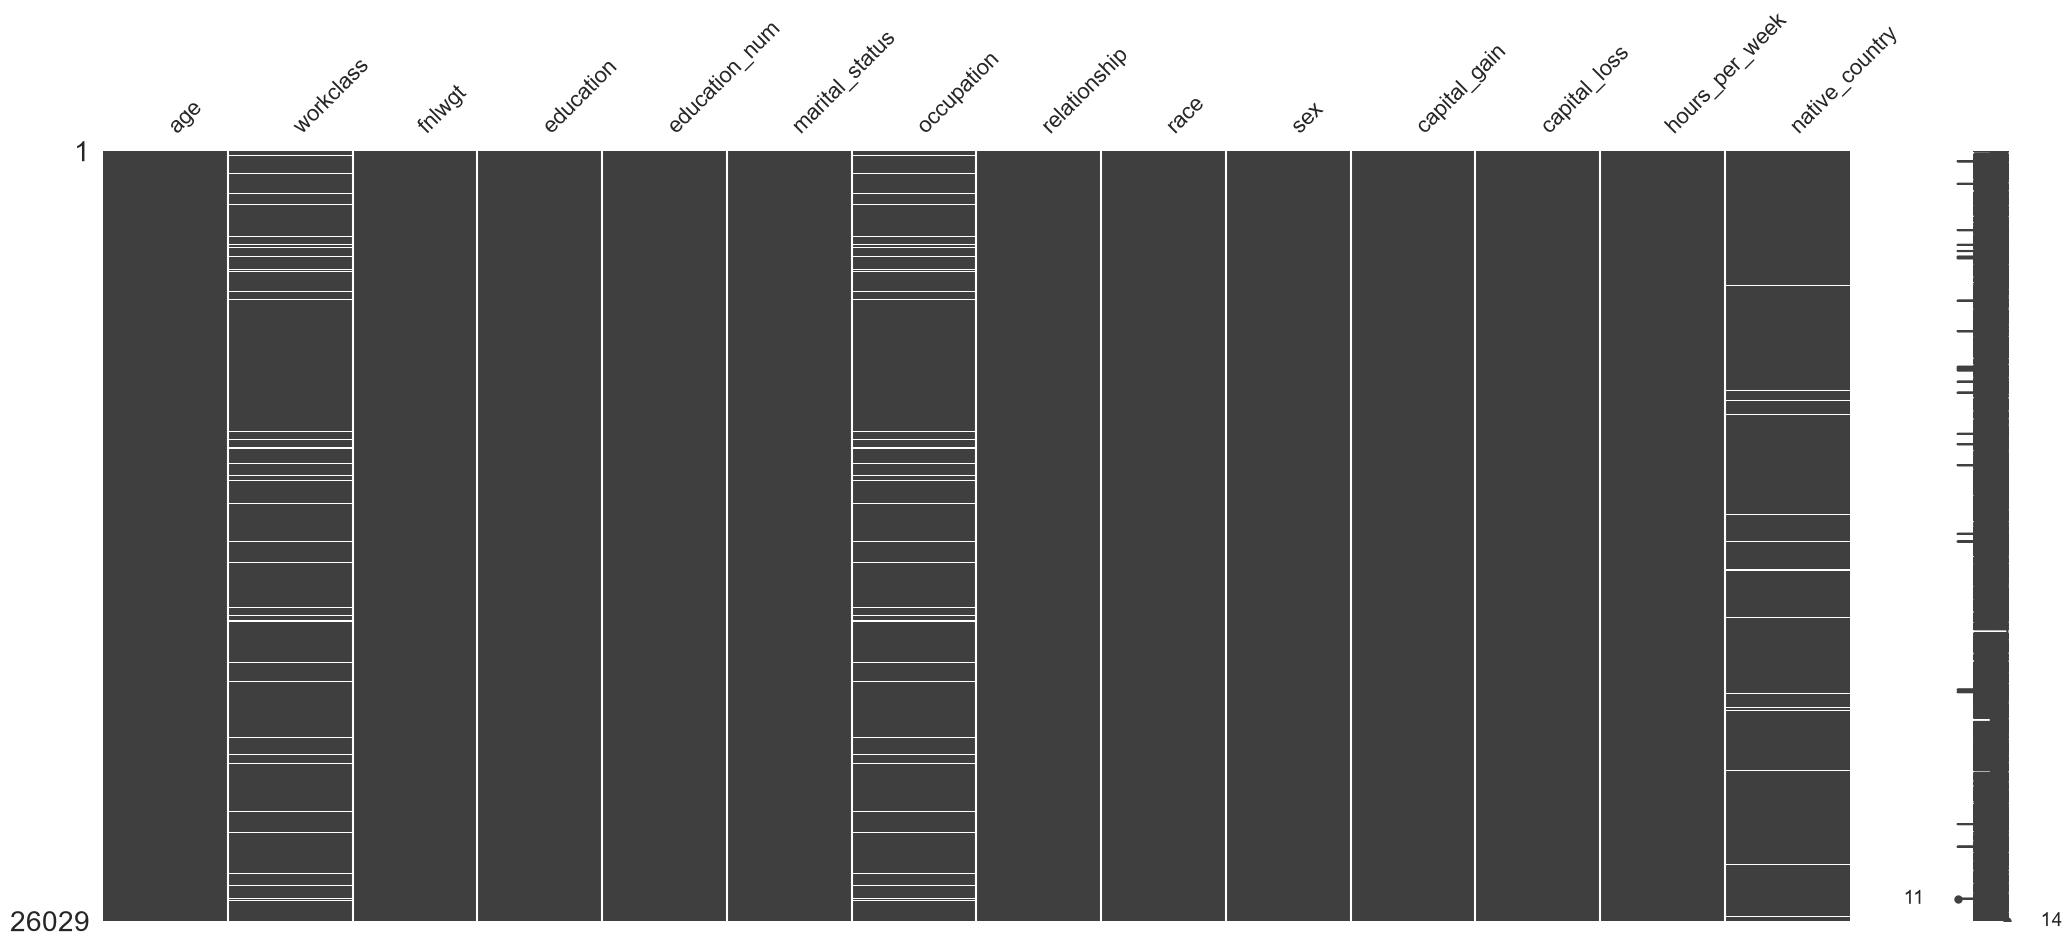

In [17]:
# missingness distribution
msno.matrix(X_train)
plt.show()

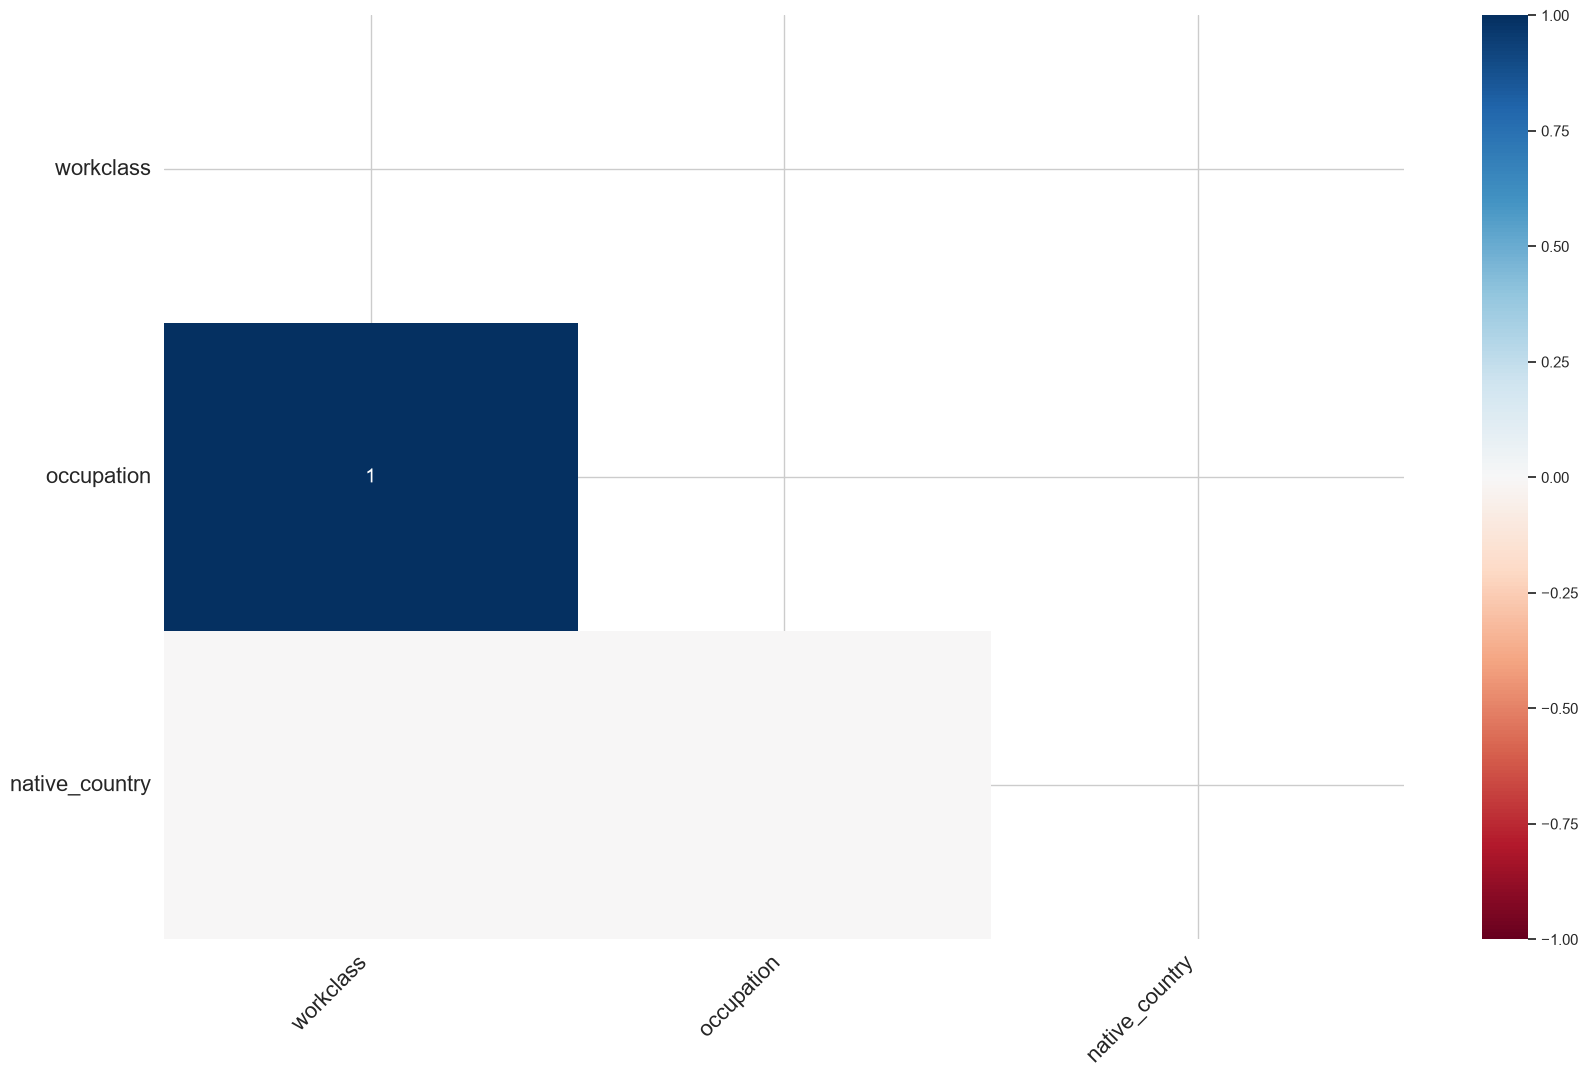

In [18]:
# missingness correlation
msno.heatmap(X_train)
plt.show()

In [19]:
# percentages of missing values
print(f"Percentages of missing values: ")
print(f"Workclass: {(X_train['workclass'].isna().sum()/len(X_train))*100:.2f}%")
print(f"Occupation: {(X_train['occupation'].isna().sum()/len(X_train))*100:.2f}%")
print(f"Native Country: {(X_train['native_country'].isna().sum()/len(X_train))*100:.2f}%")

Percentages of missing values: 
Workclass: 5.66%
Occupation: 5.68%
Native Country: 1.80%


We see the missingness of workclass and occupation are correlated in addition to the same distribution, which means the values are not randomly missing, and we are going to fill that using 'Unknown' to preserve losing informations.
For the native_country, we will basically do a simple mode filling since it has only 1.8% of missing values, and it won't affect our data distribution.

### 6.2. Imputing NaN Values

In [20]:
# workclass & occupation
for col in ['workclass', 'occupation']:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

# native_country
X_train['native_country'] = X_train['native_country'].fillna(X_train['native_country'].mode()[0])
X_test['native_country'] = X_test['native_country'].fillna(X_train['native_country'].mode()[0])

## 7. Handling Outliers

In [21]:
# description
X_train.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,26029.000000,2.602900e+04,26029.000000,26029.000000,26029.000000,26029.000000
mean,38.503899,1.898300e+05,10.080026,1095.658112,88.634638,40.438857
std,13.620717,1.058565e+05,2.572495,7466.778071,406.625857,12.287118
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.177670e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783120e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.369850e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


We see that the age, education_num, and hours_per_week have real values and don't to be clipped or removed, while the capital_gain, and capital_loss have a lot of high values and can be informative about income, we will log transform them.

In [22]:
# handling outliers
for col in ['capital_gain', 'capital_loss']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

## 8. Feature Engineering

In the adult census income, there are many categorical fetures that need to be encoded, and for this purpose, we will use:  
**One-hot encoding** for workclass, marital_status, relationship, race, and sex.  
**Target-encoding** for occupation and native country.  
And for the education_num column that is an ordinal encoding for education, but to make sure of that we need to check if each education_num value maps to a unique and order value of education.

In [23]:
# checking for education & education_num
X_train.groupby('education')['education_num'].unique()

education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: education_num, dtype: object

In [24]:
# our assumption is true, so we will drop education, plus the fnlgwt because is a census sampling weight, not a real predictive feature.
X_train = X_train.drop(columns= ['education', 'fnlwgt'])
X_test = X_test.drop(columns= ['education', 'fnlwgt'])

In [25]:
X_train.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
25267,21,Unknown,10,Never-married,Unknown,Own-child,White,Male,0.000000,0.000000,20,United-States
3349,41,Private,11,Married-civ-spouse,Sales,Husband,White,Male,8.386401,0.000000,60,United-States
4584,24,Private,9,Never-married,Handlers-cleaners,Unmarried,Black,Female,0.000000,0.000000,40,United-States
7003,59,Private,9,Widowed,Prof-specialty,Not-in-family,White,Female,0.000000,0.000000,18,United-States
882,35,Private,9,Married-civ-spouse,Sales,Husband,Asian-Pac-Islander,Male,0.000000,7.543273,50,Iran


## 9. Building Model Pipeline

In [26]:
# feature scaling + encoding
preprocessor = ColumnTransformer(
    transformers= [
        (
            'onehotencoder',
            OneHotEncoder(
                handle_unknown = 'ignore'
            ),
            ['workclass', 'marital_status', 'relationship', 'race', 'sex']
        ),
        (
            'targetencoder',
            TargetEncoder(
                target_type= 'binary'
            ),
            ['occupation', 'native_country']
        )
        ,
        (
            'scaler',
            StandardScaler(),
            ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
        )
    ],
    remainder= 'drop'
)

# pipeline
pipeline = ImbPipeline(
    [
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression())
    ]
)


## 10. Hyperparameter Tuning

In [27]:
# hyperparameter tuning
kf = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

param_grid = {
    "model__penalty": ['l1', 'l2'],
    "model__C": [0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 1, 10],
    "model__solver": ['liblinear'],
    "smote__k_neighbors": [3, 5],
    "smote__sampling_strategy": [0.5, 0.8]
}

grid = GridSearchCV(pipeline, param_grid, cv= kf, scoring= 'f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")
print(f"Best Estimator: {grid.best_estimator_}")

Best Parameters: {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'smote__k_neighbors': 5, 'smote__sampling_strategy': 0.8}
Best Score: 0.6801978182601081
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'relationship', 'race',
                                                   'sex']),
                                                 ('targetencoder',
                                                  TargetEncoder(target_type='binary'),
                                                  ['occupation',
                                                   'native_country']),
                                                 ('scaler', 

## 11. Model Training

In [28]:
# training
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [29]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      4940
           1       0.59      0.78      0.67      1568

    accuracy                           0.81      6508
   macro avg       0.75      0.80      0.77      6508
weighted avg       0.84      0.81      0.82      6508



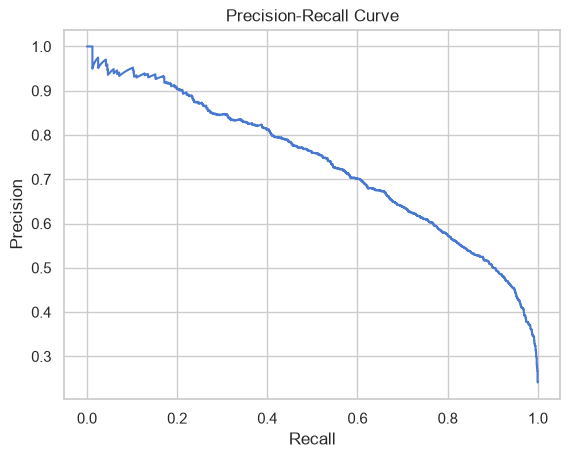

In [30]:
# threshold analysis
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(
    recall,
    precision
)

# precision recall curve
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [31]:
# spotting best threshold
f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

best_index = np.argmax(f1_scores)
threshold = thresholds[best_index]

y_pred_new = (y_prob >= threshold).astype(int)

# classification report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      4940
           1       0.60      0.77      0.67      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.80      0.78      6508
weighted avg       0.84      0.82      0.83      6508



In [32]:
# roc auc score
roc_auc_score(y_test, y_prob)

0.8943754905808479

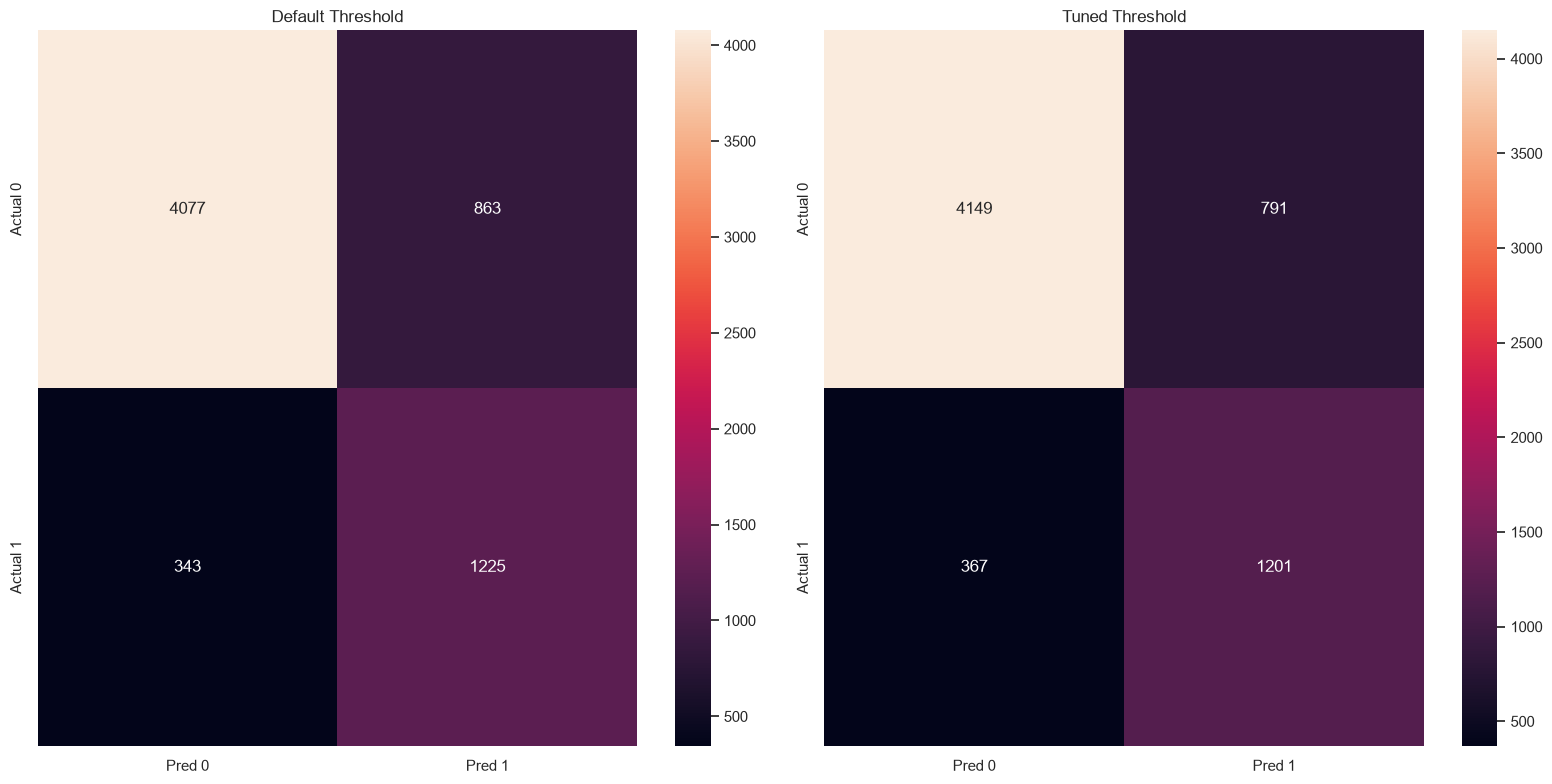

In [33]:
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16,8))

for axe, pred in zip(axes, [y_pred, y_pred_new]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot= True, ax= axe, fmt= 'd', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title("Default Threshold")
axes[-1].set_title("Tuned Threshold")
plt.tight_layout()
plt.show()